In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Song dataframe
df = pd.read_csv("../data/processed/processed_song_data.csv")
df.head()

,album,song,lyrics
0,1989 (TV),AllYouHadToDoWasStay_TaylorsVersion_,"(Hey, hey, hey) (Hey, hey, hey) (Hey, hey, hey..."
1,1989 (TV),BadBlood_TaylorsVersion_,"'Cause, baby, now we got bad blood You know it..."
2,1989 (TV),BlankSpace_TaylorsVersion_,"Nice to meet you, where you been? I could show..."
3,1989 (TV),Clean_TaylorsVersion_,"The drought was the very worst, ah-ah, ah-ah W..."
4,1989 (TV),HowYouGetTheGirl_TaylorsVersion_,"Oh, oh, oh Oh, oh, oh Oh, oh Oh, oh Stand ther..."


In [3]:
release_order = {
    'TaylorSwift': 1,
    'Fearless (TV)': 2,
    'Speak Now (TV)': 3,
    'Red (TV)': 4,
    '1989 (TV)': 5,
    'Reputation': 6,
    'Lover': 7,
    'Folklore': 8,
    'Evermore': 9,
    'Midnights': 10,
    'TTPD': 11
}

In [4]:
df['release_order'] = df['album'].map(release_order)

df.sort_values('release_order', inplace=True, ignore_index=True)
df

,album,song,lyrics,release_order
0,TaylorSwift,ColdasYou,You have a way of coming easily to me And when...,1
1,TaylorSwift,APerfectlyGoodHeart,Why would you wanna break A perfectly good hea...,1
2,TaylorSwift,TimMcGraw,He said the way my blue eyes shined Put those ...,1
3,TaylorSwift,TiedTogetherwithaSmile,Seems the only one who doesn't see your beauty...,1
4,TaylorSwift,TheOutside,I didn't know what I would find When I went lo...,1
...,...,...,...,...
221,TTPD,TheManuscript,"Now and then, she rereads the manuscript Of th...",11
222,TTPD,TheProphecy,"One, two, three, four Hand on the throttle Tho...",11
223,TTPD,TheSmallestManWhoEverLived,Was any of it true? Gazing at me starry-eyed I...,11
224,TTPD,TheTorturedPoetsDepartment,You left your typewriter at my apartment Strai...,11


In [5]:
# Album dataframe
album_df = pd.DataFrame({'album_title': df['album'].unique()})
album_df

,album_title
0,TaylorSwift
1,Fearless (TV)
2,Speak Now (TV)
3,Red (TV)
4,1989 (TV)
5,Reputation
6,Lover
7,Folklore
8,Evermore
9,Midnights


## Length of each album
How many songs in each album

In [6]:
counts = df.groupby('album', sort=False)['song'].count()

album_df['no. of songs'] = album_df['album_title'].map(counts)
album_df

,album_title,no. of songs
0,TaylorSwift,14
1,Fearless (TV),25
2,Speak Now (TV),22
3,Red (TV),28
4,1989 (TV),21
5,Reputation,15
6,Lover,18
7,Folklore,16
8,Evermore,15
9,Midnights,21


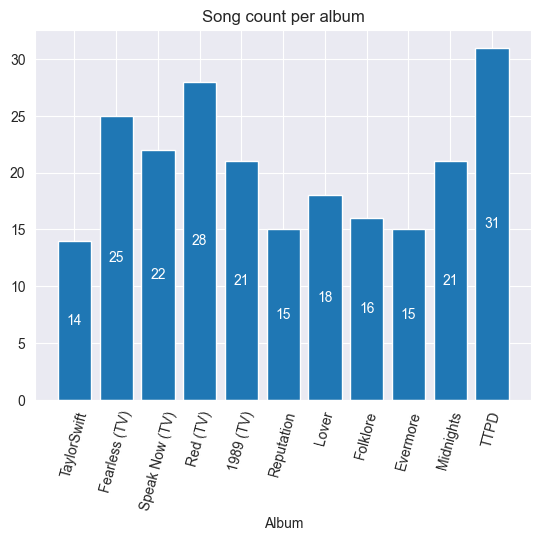

In [7]:
bars = plt.bar(counts.index, counts)
plt.xticks(rotation=75)

plt.bar_label(bars, label_type='center', color = 'white')

plt.xlabel('Album')
plt.title('Song count per album')

plt.show()

## Song length in words
And the average song length per album

In [8]:
# Example from the first song (Cold As You) of the Debut Album
song_lyrics = df.iloc[0]['lyrics']
len(song_lyrics.split(' '))

249

In [9]:
df['song_length_in_words'] = df['lyrics'].apply(lambda x: len(x.split(' ')))
df.head()

,album,song,lyrics,release_order,song_length_in_words
0,TaylorSwift,ColdasYou,You have a way of coming easily to me And when...,1,249
1,TaylorSwift,APerfectlyGoodHeart,Why would you wanna break A perfectly good hea...,1,232
2,TaylorSwift,TimMcGraw,He said the way my blue eyes shined Put those ...,1,366
3,TaylorSwift,TiedTogetherwithaSmile,Seems the only one who doesn't see your beauty...,1,254
4,TaylorSwift,TheOutside,I didn't know what I would find When I went lo...,1,234


In [10]:
# Average song length per album
avg_song_len = df.groupby('album')['song_length_in_words'].mean()

album_df['avg_song_length'] = album_df['album_title'].map(avg_song_len)
album_df['avg_song_length'] = album_df['avg_song_length'].round().astype(int)
album_df

,album_title,no. of songs,avg_song_length
0,TaylorSwift,14,287
1,Fearless (TV),25,336
2,Speak Now (TV),22,400
3,Red (TV),28,376
4,1989 (TV),21,426
5,Reputation,15,480
6,Lover,18,375
7,Folklore,16,306
8,Evermore,15,347
9,Midnights,21,336


## Tokenization, Stop word Removal and Lemmatization


In [11]:
from src.nlp_analysis import join_lyrics, tokenize, stop_word_rem, top_nouns

In [12]:
# Tokenization
album_lyrics = df.groupby('album')['lyrics'].apply(tokenize)

album_df['album_lyrics'] = album_df['album_title'].map(album_lyrics)
# album_df

In [13]:
# Stop word Removal
album_df['filtered_lyrics'] = album_df['album_lyrics'].apply(stop_word_rem)
# album_df


In [14]:
# Lemmatization
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [15]:
# loops through each album, then loops through each word in album to lemmatize it
album_df['lemmatized_lyrics'] = album_df['filtered_lyrics'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])
album_df

,album_title,no. of songs,avg_song_length,album_lyrics,filtered_lyrics,lemmatized_lyrics
0,TaylorSwift,14,287,"[you, have, a, way, of, coming, easily, to, me...","[coming, easily, take, take, best, start, figh...","[coming, easily, take, take, best, start, figh..."
1,Fearless (TV),25,336,"[this, is, wrong, but, i, ca, n't, help, but, ...","[wrong, help, feel, right, babe, misty, mornin...","[wrong, help, feel, right, babe, misty, mornin..."
2,Speak Now (TV),22,400,"[tall, ,, dark, ,, and, superman, he, puts, pa...","[tall, dark, superman, puts, papers, briefcase...","[tall, dark, superman, put, paper, briefcase, ..."
3,Red (TV),28,376,"[i, walked, through, the, door, with, you, ,, ...","[walked, door, air, cold, somethin, felt, home...","[walked, door, air, cold, somethin, felt, home..."
4,1989 (TV),21,426,"[he, said, ,, ``, let, 's, get, out, of, this,...","[said, let, town, drive, city, away, crowds, t...","[said, let, town, drive, city, away, crowd, th..."
5,Reputation,15,480,"[knew, he, was, a, killer, first, time, that, ...","[knew, killer, first, saw, wondered, many, gir...","[knew, killer, first, saw, wondered, many, gir..."
6,Lover,18,375,"[combat, ,, i, 'm, ready, for, combat, i, say,...","[combat, ready, combat, say, want, cruelty, wi...","[combat, ready, combat, say, want, cruelty, wi..."
7,Folklore,16,306,"[we, gather, here, ,, we, line, up, ,, weepin,...","[gather, line, weepin, sunlit, room, fire, mad...","[gather, line, weepin, sunlit, room, fire, mad..."
8,Evermore,15,347,"[fatefully, i, tried, to, pick, my, battles, '...","[fatefully, tried, pick, battles, battle, pick...","[fatefully, tried, pick, battle, battle, picke..."
9,Midnights,21,336,"[lock, broken, ,, slur, spoken, wound, open, ,...","[lock, broken, slur, spoken, wound, open, game...","[lock, broken, slur, spoken, wound, open, game..."


## Most common words - this is just a frequency based statistic
and most common nouns

In [16]:
from collections import Counter

In [17]:
# Top 10 words - from all words
album_df['top10_words'] = album_df['lemmatized_lyrics'].apply(lambda words: Counter(words).most_common(10))
album_df[['album_title', 'top10_words']]


,album_title,top10_words
0,TaylorSwift,"[(think, 26), (never, 25), (back, 25), (would,..."
1,Fearless (TV),"[(come, 58), (baby, 46), (say, 42), (never, 41..."
2,Speak Now (TV),"[(never, 53), (love, 49), (would, 45), (back, ..."
3,Red (TV),"[(never, 70), (back, 59), (run, 58), (love, 54..."
4,1989 (TV),"[(love, 111), (wish, 81), (say, 74), (shake, 7..."
5,Reputation,"[(made, 53), (want, 51), (call, 47), (baby, 39..."
6,Lover,"[(want, 52), (love, 44), (never, 43), (dayligh..."
7,Folklore,"[(never, 46), (would, 31), (think, 21), (gave,..."
8,Evermore,"[(could, 31), (think, 27), (never, 20), (love,..."
9,Midnights,"[(love, 38), (never, 34), (karma, 28), (around..."


In [18]:
# Top 10 Nouns
album_df['top_nouns'] = album_df['lemmatized_lyrics'].apply(top_nouns)
album_df[['album_title', 'top_nouns']]

,album_title,top_nouns
0,TaylorSwift,"[(song, 15), (baby, 14), (everything, 12), (ey..."
1,Fearless (TV),"[(baby, 41), (everything, 26), (rain, 24), (ni..."
2,Speak Now (TV),"[(life, 26), (mind, 23), (day, 21), (eye, 17),..."
3,Red (TV),"[(night, 47), (trouble, 33), (eye, 26), (love,..."
4,1989 (TV),"[(love, 81), (baby, 47), (wood, 38), (york, 30..."
5,Reputation,"[(call, 45), (baby, 33), (game, 32), (hand, 27..."
6,Lover,"[(man, 37), (daylight, 34), (baby, 27), (stree..."
7,Folklore,"[(sign, 14), (woman, 13), (everything, 11), (h..."
8,Evermore,"[(man, 15), (eye, 13), (hand, 13), (day, 11), ..."
9,Midnights,"[(love, 17), (night, 16), (someone, 15), (beac..."


In [19]:
df_plot = album_df[['album_title', 'top_nouns']].explode('top_nouns')
df_plot

,album_title,top_nouns
0,TaylorSwift,"(song, 15)"
0,TaylorSwift,"(baby, 14)"
0,TaylorSwift,"(everything, 12)"
0,TaylorSwift,"(eye, 11)"
0,TaylorSwift,"(heart, 10)"
...,...,...
10,TTPD,"(head, 13)"
10,TTPD,"(feel, 13)"
10,TTPD,"(love, 12)"
10,TTPD,"(face, 12)"


In [20]:
# Splitting the tuples above into two different columns
df_plot[['word', 'count']] = pd.DataFrame(df_plot['top_nouns'].to_list(), index=df_plot.index)
df_plot = df_plot.drop('top_nouns', axis=1)
df_plot.head(10)

,album_title,word,count
0,TaylorSwift,song,15
0,TaylorSwift,baby,14
0,TaylorSwift,everything,12
0,TaylorSwift,eye,11
0,TaylorSwift,heart,10
0,TaylorSwift,home,9
0,TaylorSwift,night,7
0,TaylorSwift,place,7
0,TaylorSwift,anyone,7
0,TaylorSwift,picture,7


Seaborn facet grid plot of the top 10 most common nouns in each album (era)

In [21]:
# sns.set_theme(style="whitegrid")
#
# # Create a grid: 3 columns wide, height adjusted by the number of albums
# noun_g = sns.FacetGrid(df_plot, col="album_title", col_wrap=4, height=4, sharex=False, sharey=False)
#
# # Map a barplot to each grid square
# noun_g.map(sns.barplot, "count", "word", color="skyblue", order=None)
#
# # Clean up titles so they aren't too long
# noun_g.set_titles("{col_name}")
# plt.tight_layout()
# plt.show()

## Type Token Ratio
A measure of Language Diversity or Vocabulary richness

In [22]:
album_df.head()

,album_title,no. of songs,avg_song_length,album_lyrics,filtered_lyrics,lemmatized_lyrics,top10_words,top_nouns
0,TaylorSwift,14,287,"[you, have, a, way, of, coming, easily, to, me...","[coming, easily, take, take, best, start, figh...","[coming, easily, take, take, best, start, figh...","[(think, 26), (never, 25), (back, 25), (would,...","[(song, 15), (baby, 14), (everything, 12), (ey..."
1,Fearless (TV),25,336,"[this, is, wrong, but, i, ca, n't, help, but, ...","[wrong, help, feel, right, babe, misty, mornin...","[wrong, help, feel, right, babe, misty, mornin...","[(come, 58), (baby, 46), (say, 42), (never, 41...","[(baby, 41), (everything, 26), (rain, 24), (ni..."
2,Speak Now (TV),22,400,"[tall, ,, dark, ,, and, superman, he, puts, pa...","[tall, dark, superman, puts, papers, briefcase...","[tall, dark, superman, put, paper, briefcase, ...","[(never, 53), (love, 49), (would, 45), (back, ...","[(life, 26), (mind, 23), (day, 21), (eye, 17),..."
3,Red (TV),28,376,"[i, walked, through, the, door, with, you, ,, ...","[walked, door, air, cold, somethin, felt, home...","[walked, door, air, cold, somethin, felt, home...","[(never, 70), (back, 59), (run, 58), (love, 54...","[(night, 47), (trouble, 33), (eye, 26), (love,..."
4,1989 (TV),21,426,"[he, said, ,, ``, let, 's, get, out, of, this,...","[said, let, town, drive, city, away, crowds, t...","[said, let, town, drive, city, away, crowd, th...","[(love, 111), (wish, 81), (say, 74), (shake, 7...","[(love, 81), (baby, 47), (wood, 38), (york, 30..."


In [23]:
from src.nlp_analysis import type_token_ratio

In [24]:
album_df['type_token_ratio'] = album_df['album_lyrics'].apply(type_token_ratio)
album_df[['album_title', 'type_token_ratio']]

,album_title,type_token_ratio
0,TaylorSwift,0.296
1,Fearless (TV),0.332
2,Speak Now (TV),0.342
3,Red (TV),0.456
4,1989 (TV),0.314
5,Reputation,0.288
6,Lover,0.344
7,Folklore,0.402
8,Evermore,0.370
9,Midnights,0.342


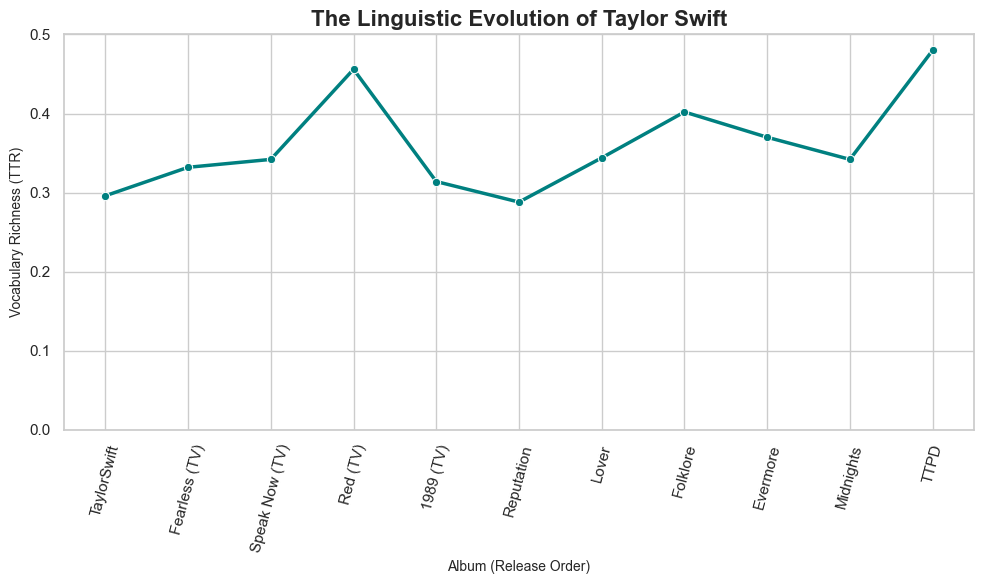

In [27]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.lineplot(data=album_df, x='album_title', y='type_token_ratio', marker='o', color='teal', linewidth=2.5)

plt.title('The Linguistic Evolution of Taylor Swift', fontsize=16, fontweight='bold')
plt.xlabel('Album (Release Order)', fontsize=10)
plt.ylabel('Vocabulary Richness (TTR)', fontsize=10)

plt.xticks(rotation=75)
plt.ylim(0, 0.5)
plt.tight_layout()
plt.show()

## TF-IDF
Term Frequency - Inverse Document Frequency: Highlighting the popular words from one album that dont appear in the others

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
# Converting each album's lyrics into one long string rather than a list
corpus = album_df['lemmatized_lyrics'].apply(lambda x: " ".join(x))

In [24]:
# Create and tune the TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_df = 0.7,
)
response = tfidf.fit_transform(corpus)
response # result is a matrix of floating point numbers


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7044 stored elements and shape (11, 3604)>

In [25]:
tfidf_df = pd.DataFrame(
    data = response.toarray(),
    index = album_df['album_title'],
    columns = tfidf.get_feature_names_out()
)
tfidf_df

,abandoned,abigail,ablaze,absolutely,absurd,abusive,accent,accident,accidental,account,...,yogurt,york,young,younger,youth,yеah,yеt,еclipse,еverybody,еxchanged
album_title,,,,,,,,,,,,,,,,,,,,,
TaylorSwift,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
Fearless (TV),0.000000,0.035937,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.018092,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
Speak Now (TV),0.000000,0.000000,0.000000,0.01917,0.01917,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.010567,0.057904,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.01917
Red (TV),0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.030815,0.035176,0.000000,0.011945,0.0000,0.000000,0.000000,0.013975,0.00000
1989 (TV),0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.196799,0.035945,0.000000,0.000000,0.0119,0.000000,0.000000,0.000000,0.00000
Reputation,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.009545,0.016207,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
Lover,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.015921,0.054434,0.000000,0.000000,...,0.000000,0.026330,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
Folklore,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.026731,0.014736,0.067287,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
Evermore,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.018626,0.000000,0.018626,...,0.000000,0.000000,0.000000,0.018626,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000


In [27]:
# EXAMPLE - Top 10 words with TF-IDF from the Debut Album
top_words = tfidf_df.iloc[0].sort_values(ascending=False).head(10)
top_words

tim          0.213601
mcgraw       0.213601
perfectly    0.191326
truck        0.182578
anyone       0.167410
mama         0.160567
radio        0.152148
outside      0.151135
undone       0.143494
late         0.143378
Name: TaylorSwift, dtype: float64

In [28]:
# Loop through all albums to find the top 10 words from the TF-IDF (top 10 words that appear in the album that don't appear in the others)
theme_dict = {}

for index, row in tfidf_df.iterrows():
    tfidf_top_10 = row.sort_values(ascending=False).head(10)

    top_tuples_clean = [(word, round(float(score), 3)) for word, score in zip(tfidf_top_10.index, tfidf_top_10.values)]

    theme_dict[index] = top_tuples_clean

In [29]:
album_df['tfidf_top_10'] = album_df['album_title'].map(theme_dict)
album_df[['album_title', 'tfidf_top_10']]

,album_title,tfidf_top_10
0,TaylorSwift,"[(tim, 0.214), (mcgraw, 0.214), (perfectly, 0...."
1,Fearless (TV),"[(bye, 0.467), (fairytale, 0.341), (today, 0.2..."
2,Speak Now (TV),"[(grow, 0.267), (emma, 0.173), (timeless, 0.17..."
3,Red (TV),"[(red, 0.415), (trouble, 0.394), (starlight, 0..."
4,1989 (TV),"[(shake, 0.505), (wood, 0.452), (wonderland, 0..."
5,Reputation,"[(getaway, 0.417), (gorgeous, 0.303), (reputat..."
6,Lover,"[(daylight, 0.637), (cornelia, 0.255), (bless,..."
7,Folklore,"[(woman, 0.261), (warning, 0.183), (film, 0.18..."
8,Evermore,"[(happiness, 0.224), (closure, 0.218), (prove,..."
9,Midnights,"[(karma, 0.385), (beach, 0.194), (fallin, 0.18..."
